In [6]:
# Cell 1: Import & thiết lập môi trường
import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

SEED = 42
def seed_everything(seed=42):
    random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
os.makedirs("outputs", exist_ok=True)
print("Seed:", SEED, "| PyTorch:", torch.__version__)

Seed: 42 | PyTorch: 2.14.0+cpu


In [7]:
# Cell 2: CNN From Scratch NumPy — Conv1D, ReLU, MaxPool1D, Flatten,
#         Dense, Sigmoid, BCE Loss, Adam, Training Loop
import numpy as np

class Layer:
    def __init__(self):
        self.params, self.grads = {}, {}
    def forward(self, x): raise NotImplementedError
    def backward(self, dout): raise NotImplementedError

class Conv1D(Layer):
    """Conv1D với He init, hỗ trợ batch, kernel trượt vectorized."""
    def __init__(self, in_ch, out_ch, k=3, stride=1, padding=0, seed=42):
        super().__init__()
        self.in_ch, self.out_ch = in_ch, out_ch
        self.k, self.stride, self.pad = k, stride, padding
        rng = np.random.default_rng(seed)
        limit = np.sqrt(2.0 / (in_ch * k))
        self.params['W'] = (rng.standard_normal((out_ch, in_ch, k)) * limit).astype(np.float32)
        self.params['b'] = np.zeros((out_ch, 1), dtype=np.float32)
        self.grads['W'] = np.zeros_like(self.params['W'])
        self.grads['b'] = np.zeros_like(self.params['b'])

    def forward(self, X):
        self.X = X
        N, C, L = X.shape
        self.X_pad = np.pad(X, ((0,0),(0,0),(self.pad,self.pad)), 'constant') if self.pad>0 else X
        L_out = (L + 2*self.pad - self.k)//self.stride + 1
        out = np.zeros((N, self.out_ch, L_out), dtype=np.float32)
        for i in range(L_out):
            s = i*self.stride; e = s + self.k
            patch = self.X_pad[:, :, s:e]
            out[:, :, i] = np.tensordot(patch, self.params['W'],
                                        axes=([1,2],[1,2])) + self.params['b'].ravel()
        self.L_out = L_out
        return out

    def backward(self, dout):
        N, C_out, L_out = dout.shape
        self.grads['b'] = dout.sum(axis=(0,2)).reshape(-1,1).astype(np.float32)
        self.grads['W'] = np.zeros_like(self.params['W'])
        dX_pad = np.zeros_like(self.X_pad)
        for i in range(L_out):
            s = i*self.stride; e = s + self.k
            patch = self.X_pad[:, :, s:e]
            g = dout[:, :, i]
            self.grads['W'] += np.tensordot(g, patch, axes=([0],[0]))
            dX_pad[:, :, s:e] += np.tensordot(g, self.params['W'], axes=([1],[0]))
        return dX_pad[:, :, self.pad:-self.pad] if self.pad>0 else dX_pad

class ReLU(Layer):
    def forward(self, X):
        self.mask = X > 0
        return X * self.mask
    def backward(self, dout):
        return dout * self.mask

class MaxPool1D(Layer):
    def __init__(self, size=2, stride=2):
        super().__init__(); self.size, self.stride = size, stride
    def forward(self, X):
        self.X = X
        N, C, L = X.shape
        L_out = (L - self.size)//self.stride + 1
        out = np.zeros((N, C, L_out), dtype=np.float32)
        self.argmax = np.zeros((N, C, L_out), dtype=np.int32)
        for i in range(L_out):
            s = i*self.stride; e = s + self.size
            patch = X[:, :, s:e]
            out[:, :, i] = patch.max(axis=2)
            self.argmax[:, :, i] = patch.argmax(axis=2) + s
        return out
    def backward(self, dout):
        N, C, L_out = dout.shape
        dX = np.zeros_like(self.X)
        for i in range(L_out):
            for n in range(N):
                for c in range(C):
                    dX[n, c, self.argmax[n, c, i]] += dout[n, c, i]
        return dX

class Flatten(Layer):
    def forward(self, X):
        self.shape = X.shape; return X.reshape(X.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.shape)

class Dense(Layer):
    def __init__(self, in_f, out_f, seed=42):
        super().__init__()
        rng = np.random.default_rng(seed)
        limit = np.sqrt(2.0 / in_f)
        self.params['W'] = (rng.standard_normal((in_f, out_f))*limit).astype(np.float32)
        self.params['b'] = np.zeros((1, out_f), dtype=np.float32)
        self.grads['W'] = np.zeros_like(self.params['W'])
        self.grads['b'] = np.zeros_like(self.params['b'])
    def forward(self, X):
        self.X = X; return X @ self.params['W'] + self.params['b']
    def backward(self, dout):
        N = self.X.shape[0]
        self.grads['W'] = (self.X.T @ dout) / N
        self.grads['b'] = dout.sum(axis=0, keepdims=True) / N
        return dout @ self.params['W'].T

class Sigmoid(Layer):
    def forward(self, X):
        self.out = 1.0/(1.0 + np.exp(-np.clip(X, -50, 50))); return self.out
    def backward(self, dout):
        return dout * self.out * (1.0 - self.out)

def bce_loss(y_pred, y_true):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1-eps)
    loss = -np.mean(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))
    dpred = (y_pred - y_true)/(y_pred*(1-y_pred))/y_true.shape[0]
    return loss, dpred.astype(np.float32)

class AdamOptimizer:
    def __init__(self, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m, self.v, self.t = {}, {}, 0
    def step(self, layers):
        self.t += 1
        for idx, layer in enumerate(layers):
            for name in layer.params:
                key = f"{idx}_{name}"
                g = layer.grads[name]
                if key not in self.m:
                    self.m[key] = np.zeros_like(g); self.v[key] = np.zeros_like(g)
                self.m[key] = self.b1*self.m[key] + (1-self.b1)*g
                self.v[key] = self.b2*self.v[key] + (1-self.b2)*(g**2)
                m_hat = self.m[key]/(1-self.b1**self.t)
                v_hat = self.v[key]/(1-self.b2**self.t)
                layer.params[name] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

class NumPyCNN:
    """CNN 1D hoàn chỉnh cho tabular."""
    def __init__(self, in_ch=1, input_len=8, n_filters=(16,32),
                 hidden=32, dropout=0.0, lr=1e-3, seed=42):
        super().__init__()
        self.conv1 = Conv1D(in_ch, n_filters[0], 3, padding=1, seed=seed)
        self.relu1 = ReLU()
        self.conv2 = Conv1D(n_filters[0], n_filters[1], 3, padding=1, seed=seed+1)
        self.relu2 = ReLU()
        self.pool = MaxPool1D(2, 2)
        self.flatten = Flatten()
        pooled_len = input_len // 2
        self.dense1 = Dense(n_filters[1]*pooled_len, hidden, seed=seed+2)
        self.relu3 = ReLU()
        self.dense2 = Dense(hidden, 1, seed=seed+3)
        self.sigmoid = Sigmoid()
        self.dropout = dropout
        self.layers = [self.conv1, self.conv2, self.dense1, self.dense2]
        self.opt = AdamOptimizer(lr=lr)
        self.cache = {}
        self.rng = np.random.default_rng(seed)

    def forward(self, X, training=True):
        z1 = self.conv1.forward(X);   a1 = self.relu1.forward(z1)
        z2 = self.conv2.forward(a1);  a2 = self.relu2.forward(z2)
        p = self.pool.forward(a2);    f = self.flatten.forward(p)
        z3 = self.dense1.forward(f);  a3 = self.relu3.forward(z3)
        if training and self.dropout > 0:
            mask = (self.rng.random(a3.shape) > self.dropout) / (1 - self.dropout)
            a3 = a3 * mask; self.cache['drop_mask'] = mask
        else:
            self.cache.pop('drop_mask', None)
        z4 = self.dense2.forward(a3)
        out = self.sigmoid.forward(z4)
        self.cache.update({'z1':z1,'a1':a1,'z2':z2,'a2':a2,
                           'p':p,'f':f,'z3':z3,'a3':a3,'out':out})
        return out

    def backward(self, dpred):
        d = self.sigmoid.backward(dpred)
        d = self.dense2.backward(d)
        if 'drop_mask' in self.cache: d = d * self.cache['drop_mask']
        d = self.relu3.backward(d)
        d = self.dense1.backward(d)
        d = self.flatten.backward(d)
        d = self.pool.backward(d)
        d = self.relu2.backward(d)
        d = self.conv2.backward(d)
        d = self.relu1.backward(d)
        self.conv1.backward(d)

    def predict_proba(self, X):
        return self.forward(X, training=False).ravel()

    def fit(self, X_tr, y_tr, X_val, y_val, epochs=30, batch_size=32):
        history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
        N = len(X_tr)
        for epoch in range(epochs):
            idx = np.random.permutation(N); ep_loss = 0.0
            for s in range(0, N, batch_size):
                bidx = idx[s:s+batch_size]
                pred = self.forward(X_tr[bidx], training=True)
                loss, dpred = bce_loss(pred, y_tr[bidx].reshape(-1,1))
                self.backward(dpred); self.opt.step(self.layers)
                ep_loss += loss * len(bidx)
            ep_loss /= N
            tr_p = self.predict_proba(X_tr); val_p = self.predict_proba(X_val)
            tr_loss,_ = bce_loss(tr_p.reshape(-1,1), y_tr.reshape(-1,1))
            val_loss,_ = bce_loss(val_p.reshape(-1,1), y_val.reshape(-1,1))
            history['train_loss'].append(tr_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(((tr_p>=0.5).astype(int)==y_tr).mean())
            history['val_acc'].append(((val_p>=0.5).astype(int)==y_val).mean())
            if epoch % 5 == 0 or epoch == epochs-1:
                print(f"Epoch {epoch+1:02d}/{epochs} | loss={tr_loss:.4f} | "
                      f"val_loss={val_loss:.4f} | val_acc={history['val_acc'][-1]:.4f}")
        return history

print("Đã định nghĩa xong CNN From Scratch NumPy.")

Đã định nghĩa xong CNN From Scratch NumPy.


In [9]:
# Cell 3: Kiểm chứng số học theo Slide 18 (Conv1D + ReLU)
conv = Conv1D(in_ch=1, out_ch=1, k=3, stride=1, padding=0, seed=0)
relu = ReLU()
conv.params['W'] = np.array([0.5, -1.0, 0.5]).reshape(1,1,3)
conv.params['b'] = np.array([[0.0]])

x_in = np.array([2.,1.,3.,4.,2.]).reshape(1,1,5)
z = conv.forward(x_in); a = relu.forward(z)
print("z =", z.flatten().tolist(), "| Kỳ vọng [1.5, -0.5, -1.5]")
print("a =", a.flatten().tolist(), "| Kỳ vọng [1.5, 0.0, 0.0]")
assert np.allclose(z.flatten(), [1.5,-0.5,-1.5]) and np.allclose(a.flatten(), [1.5,0,0])
print("=> Khớp chính xác theo Slide 18")

z = [1.5, -0.5, -1.5] | Kỳ vọng [1.5, -0.5, -1.5]
a = [1.5, -0.0, -0.0] | Kỳ vọng [1.5, 0.0, 0.0]
=> Khớp chính xác theo Slide 18


In [10]:
# Cell 4: Load Diabetes + Preprocessing + Split
df = pd.read_csv("diabetes.csv")
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)

X = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val_raw, X_te_raw, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_tr = scaler.fit_transform(imputer.fit_transform(X_tr_raw)).astype(np.float32)
X_val = scaler.transform(imputer.transform(X_val_raw)).astype(np.float32)
X_te = scaler.transform(imputer.transform(X_te_raw)).astype(np.float32)

print(f"Train/Val/Test: {X_tr.shape}/{X_val.shape}/{X_te.shape}")
print(f"Positive rate train: {y_tr.mean():.4f}")

# DataLoader cho PyTorch (channel-first)
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr).unsqueeze(1), torch.tensor(y_tr, dtype=torch.long)),
    batch_size=32, shuffle=True)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val).unsqueeze(1), torch.tensor(y_val, dtype=torch.long)),
    batch_size=32, shuffle=False)
X_te_t = torch.tensor(X_te).unsqueeze(1)

Train/Val/Test: (537, 8)/(115, 8)/(116, 8)
Positive rate train: 0.3482


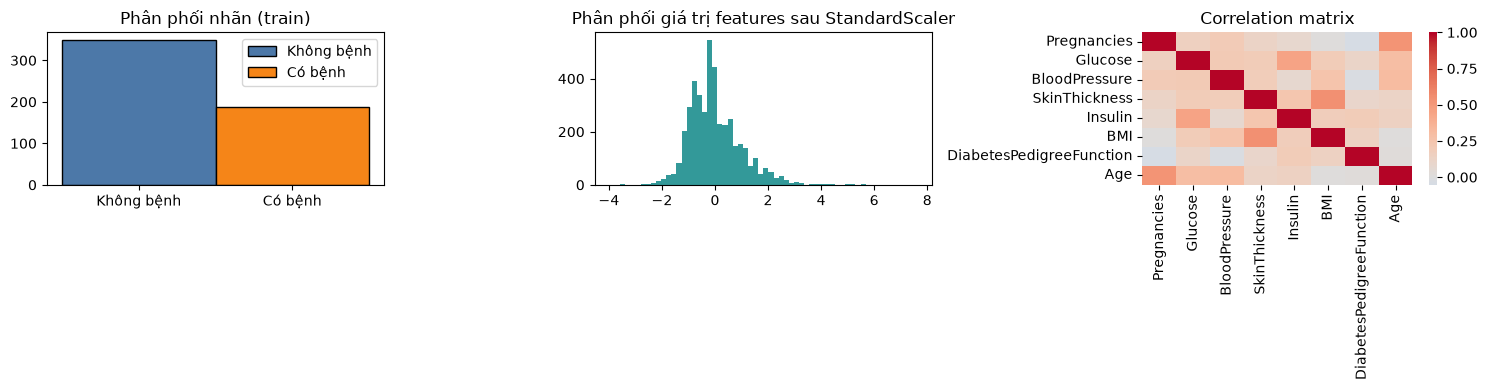

In [12]:
# Cell 5: EDA - Histogram pixel, phân phối nhãn, correlation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sửa lỗi ở đây: Tách y_tr thành 2 phần để tô 2 màu
axes[0].hist(y_tr[y_tr == 0], bins=[-0.5, 0.5], edgecolor='black', color='#4C78A8', label='Không bệnh')
axes[0].hist(y_tr[y_tr == 1], bins=[0.5, 1.5], edgecolor='black', color='#F58518', label='Có bệnh')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Không bệnh', 'Có bệnh'])
axes[0].set_title("Phân phối nhãn (train)")
axes[0].legend()

axes[1].hist(X_tr.ravel(), bins=60, color='teal', alpha=0.8)
axes[1].set_title("Phân phối giá trị features sau StandardScaler")

corr = pd.DataFrame(X_tr, columns=df.columns[:-1]).corr()
sns.heatmap(corr, ax=axes[2], cmap='coolwarm', center=0, cbar=True,
            xticklabels=df.columns[:-1], yticklabels=df.columns[:-1])
axes[2].set_title("Correlation matrix")

plt.tight_layout(); plt.savefig("outputs/diabetes_eda.png", dpi=200); plt.show()

In [13]:
# Cell 6: Baseline CNN (Conv → ReLU → Pool → Conv → ReLU → Pool → FC)
class BaselineCNN(nn.Module):
    def __init__(self, in_len=8, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (in_len//4), 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def train_pt_model(model, train_loader, val_loader, epochs=40, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    t0 = time.time()
    for ep in range(epochs):
        model.train(); tr_loss, tr_corr, n = 0., 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tr_loss += loss.item()*len(yb)
            tr_corr += (out.argmax(1) == yb).sum().item(); n += len(yb)
        model.eval(); val_loss, val_corr, vn = 0., 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb); loss = criterion(out, yb)
                val_loss += loss.item()*len(yb)
                val_corr += (out.argmax(1) == yb).sum().item(); vn += len(yb)
        history['train_loss'].append(tr_loss/n)
        history['val_loss'].append(val_loss/vn)
        history['train_acc'].append(tr_corr/n)
        history['val_acc'].append(val_corr/vn)
    return history, time.time()-t0

seed_everything(SEED)
baseline = BaselineCNN()
hist_baseline, time_baseline = train_pt_model(baseline, train_loader, val_loader, epochs=40)
print(f"Baseline CNN — Time: {time_baseline:.2f}s")

Baseline CNN — Time: 4.66s


In [14]:
# Cell 7: Improved CNN (+ BatchNorm + Dropout)
class ImprovedCNN(nn.Module):
    def __init__(self, in_len=8, n_classes=2, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64 * (in_len//4), 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

seed_everything(SEED)
improved = ImprovedCNN()
hist_improved, time_improved = train_pt_model(improved, train_loader, val_loader, epochs=40)
print(f"Improved CNN — Time: {time_improved:.2f}s")

Improved CNN — Time: 4.51s


In [16]:
# Cell 8: Ablation Study M1–M4 (M3 thêm Residual, M4 thêm SE-Block)
class SEBlock1D(nn.Module):
    """Squeeze-and-Excitation cho 1D."""
    def __init__(self, ch, r=4):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r), nn.ReLU(),
            nn.Linear(ch//r, ch), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        s = self.fc(self.gap(x).view(b, c)).view(b, c, 1)
        return x * s.expand_as(x)

class ResBlock1D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch), nn.ReLU(),
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch)
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.body(x))

class CNNVariant(nn.Module):
    """variant: 1=baseline, 2=+BN, 3=+Residual, 4=+SE"""
    def __init__(self, variant=1, in_len=8, n_classes=2, dropout=0.3):
        super().__init__()
        self.variant = variant
        use_bn = variant >= 2
        use_res = variant >= 3
        use_se = variant >= 4

        def block(cin, cout):
            layers = [nn.Conv1d(cin, cout, 3, padding=1)]
            if use_bn: layers.append(nn.BatchNorm1d(cout))
            layers.append(nn.ReLU())
            return nn.Sequential(*layers)

        self.stem = block(1, 32)
        self.pool = nn.MaxPool1d(2)
        self.res = ResBlock1D(32) if use_res else nn.Identity()
        self.se  = SEBlock1D(32) if use_se  else nn.Identity()
        self.trans = block(32, 64)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64 * (in_len // 2), 32), nn.ReLU(), 
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        x = self.stem(x); x = self.pool(x)
        x = self.se(self.res(x))
        x = self.trans(x)
        return self.classifier(x)

ablation_results = {}
for v in [1, 2, 3, 4]:
    seed_everything(SEED)
    m = CNNVariant(variant=v)
    hist, t = train_pt_model(m, train_loader, val_loader, epochs=30)
    n_params = sum(p.numel() for p in m.parameters())
    ablation_results[v] = {'hist': hist, 'time': t, 'params': n_params,
                            'val_acc': hist['val_acc'][-1]}
    print(f"M{v} — Params={n_params} | Time={t:.1f}s | Val Acc={hist['val_acc'][-1]:.4f}")

M1 — Params=14626 | Time=2.7s | Val Acc=0.7217
M2 — Params=14818 | Time=3.2s | Val Acc=0.7217
M3 — Params=21154 | Time=5.6s | Val Acc=0.7304
M4 — Params=21706 | Time=6.0s | Val Acc=0.7478


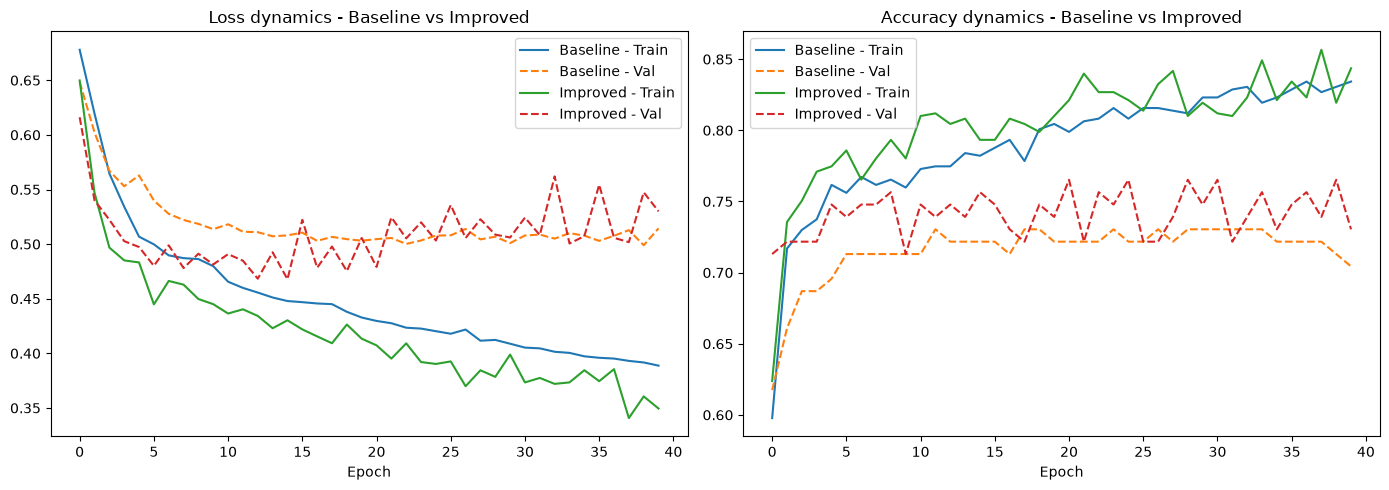

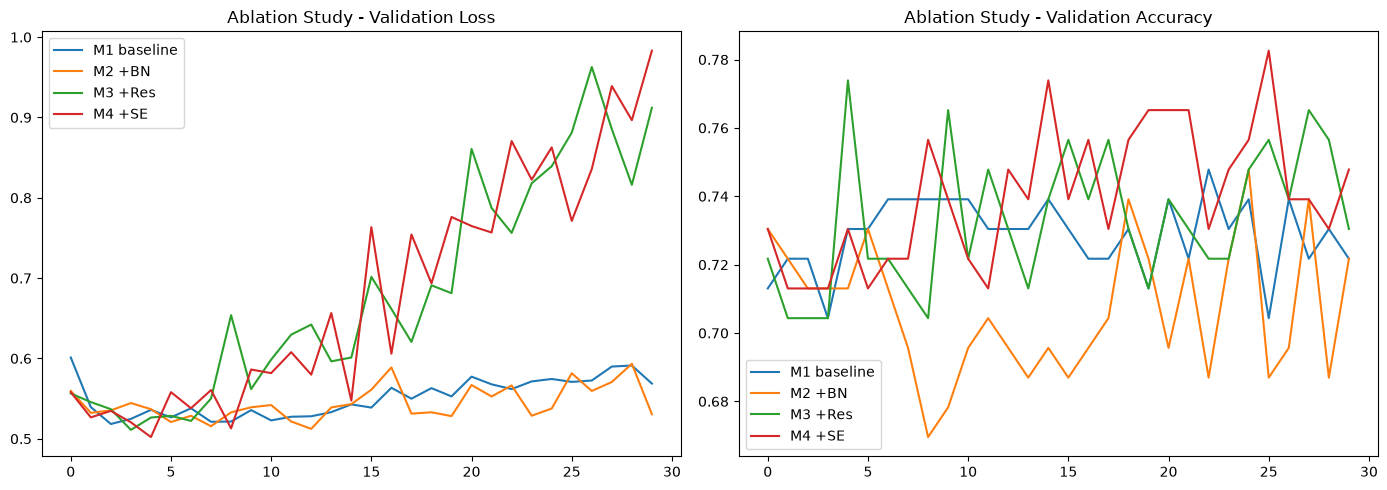

In [17]:
# Cell 9: Vẽ training curves Baseline vs Improved + M1-M4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_baseline['train_loss'], label='Baseline - Train')
axes[0].plot(hist_baseline['val_loss'], label='Baseline - Val', ls='--')
axes[0].plot(hist_improved['train_loss'], label='Improved - Train')
axes[0].plot(hist_improved['val_loss'], label='Improved - Val', ls='--')
axes[0].set_title("Loss dynamics - Baseline vs Improved")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(hist_baseline['train_acc'], label='Baseline - Train')
axes[1].plot(hist_baseline['val_acc'], label='Baseline - Val', ls='--')
axes[1].plot(hist_improved['train_acc'], label='Improved - Train')
axes[1].plot(hist_improved['val_acc'], label='Improved - Val', ls='--')
axes[1].set_title("Accuracy dynamics - Baseline vs Improved")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.savefig("outputs/diabetes_curves.png", dpi=200); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for v, name in zip([1,2,3,4], ['M1 baseline','M2 +BN','M3 +Res','M4 +SE']):
    axes[0].plot(ablation_results[v]['hist']['val_loss'], label=name)
    axes[1].plot(ablation_results[v]['hist']['val_acc'], label=name)
axes[0].set_title("Ablation Study - Validation Loss"); axes[0].legend()
axes[1].set_title("Ablation Study - Validation Accuracy"); axes[1].legend()
plt.tight_layout(); plt.savefig("outputs/diabetes_ablation.png", dpi=200); plt.show()


--- Baseline CNN ---
Accuracy: 0.7586 | F1: 0.6216 | ROC-AUC: 0.8455
              precision    recall  f1-score   support

  Không bệnh       0.78      0.87      0.82        75
     Có bệnh       0.70      0.56      0.62        41

    accuracy                           0.76       116
   macro avg       0.74      0.71      0.72       116
weighted avg       0.75      0.76      0.75       116


--- Improved CNN ---
Accuracy: 0.7586 | F1: 0.6111 | ROC-AUC: 0.8358
              precision    recall  f1-score   support

  Không bệnh       0.78      0.88      0.82        75
     Có bệnh       0.71      0.54      0.61        41

    accuracy                           0.76       116
   macro avg       0.74      0.71      0.72       116
weighted avg       0.75      0.76      0.75       116



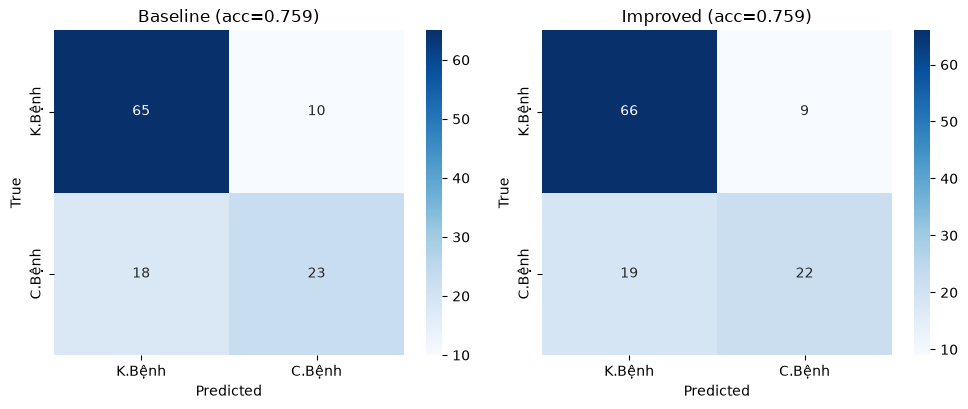

In [18]:
# Cell 10: Evaluate baseline và improved
def evaluate_model(model, X_tensor, y_true, name):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor.to(device))
        probs = torch.softmax(logits, 1)[:,1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
    acc = accuracy_score(y_true, preds); f1 = f1_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_true, preds,
          target_names=['Không bệnh','Có bệnh']))
    return acc, f1, auc, probs, preds

acc_b, f1_b, auc_b, prob_b, pred_b = evaluate_model(baseline, X_te_t, y_te, "Baseline CNN")
acc_i, f1_i, auc_i, prob_i, pred_i = evaluate_model(improved, X_te_t, y_te, "Improved CNN")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, cm, t in zip(axes, [confusion_matrix(y_te, pred_b), confusion_matrix(y_te, pred_i)],
                     [f"Baseline (acc={acc_b:.3f})", f"Improved (acc={acc_i:.3f})"]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['K.Bệnh','C.Bệnh'], yticklabels=['K.Bệnh','C.Bệnh'])
    ax.set_title(t); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig("outputs/diabetes_confusion.png", dpi=200); plt.show()

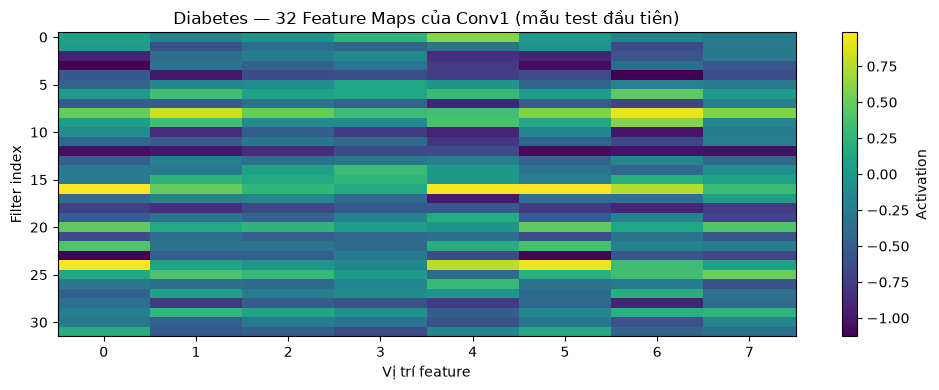

In [19]:
# Cell 11: Feature maps lớp Conv1 đầu tiên của Improved CNN
improved.eval()
with torch.no_grad():
    fmaps = improved.features[0](X_te_t[0:1]).squeeze(0).cpu().numpy()  # (32, L)
plt.figure(figsize=(10, 4))
plt.imshow(fmaps, aspect='auto', cmap='viridis')
plt.colorbar(label='Activation')
plt.title("Diabetes — 32 Feature Maps của Conv1 (mẫu test đầu tiên)")
plt.xlabel("Vị trí feature"); plt.ylabel("Filter index")
plt.tight_layout(); plt.savefig("outputs/diabetes_feature_maps.png", dpi=200); plt.show()

In [20]:
# Cell 12: High-confidence error analysis
def high_conf_errors(y_true, y_prob, top_k=10, thresh=0.9):
    y_pred = (y_prob >= 0.5).astype(int)
    wrong = y_pred != y_true
    conf = np.where(y_pred == 1, y_prob, 1 - y_prob)
    sel = wrong & (conf >= thresh)
    idx = np.where(sel)[0]
    idx = idx[np.argsort(-conf[idx])][:top_k]
    return pd.DataFrame({
        'idx': idx, 'true': y_true[idx], 'pred': y_pred[idx],
        'confidence': conf[idx], 'prob_diabetes': y_prob[idx]
    })

err_df = high_conf_errors(y_te, prob_i, top_k=15, thresh=0.85)
print("HIGH-CONFIDENCE ERRORS (Improved CNN):")
print(err_df.to_string(index=False))
err_df.to_csv("outputs/diabetes_high_conf_errors.csv", index=False)

HIGH-CONFIDENCE ERRORS (Improved CNN):
 idx  true  pred  confidence  prob_diabetes
 108     1     0    0.981148       0.018852
 112     1     0    0.976244       0.023756
  10     1     0    0.965051       0.034949
 107     0     1    0.959861       0.959861
 106     1     0    0.958427       0.041573
  31     1     0    0.954252       0.045748
  40     1     0    0.915326       0.084674
  61     1     0    0.900668       0.099332
   7     0     1    0.876069       0.876069
 105     1     0    0.875109       0.124891
  72     1     0    0.872944       0.127056


Epoch 01/30 | loss=0.5047 | val_loss=0.5497 | val_acc=0.6870
Epoch 06/30 | loss=0.4218 | val_loss=0.5504 | val_acc=0.6957
Epoch 11/30 | loss=0.3923 | val_loss=0.5453 | val_acc=0.7043
Epoch 16/30 | loss=0.3611 | val_loss=0.5491 | val_acc=0.7217
Epoch 21/30 | loss=0.3318 | val_loss=0.5566 | val_acc=0.7391
Epoch 26/30 | loss=0.3054 | val_loss=0.5590 | val_acc=0.7304
Epoch 30/30 | loss=0.2798 | val_loss=0.5744 | val_acc=0.7391

NumPy Scratch — Acc=0.7586 | F1=0.6111 | Params=5793 | Time=3.42s


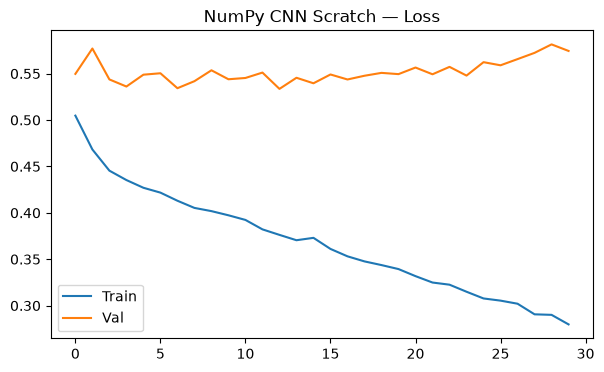

In [21]:
# Cell 13: Train NumPy CNN from scratch trên Diabetes
X_tr_seq = X_tr[..., None].transpose(0,2,1).astype(np.float32)
X_val_seq = X_val[..., None].transpose(0,2,1).astype(np.float32)
X_te_seq  = X_te[..., None].transpose(0,2,1).astype(np.float32)

np_model = NumPyCNN(in_ch=1, input_len=8, n_filters=(16,32), hidden=32,
                    dropout=0.0, lr=1e-3, seed=SEED)
t0 = time.time()
hist_np = np_model.fit(X_tr_seq, y_tr.astype(np.float32),
                       X_val_seq, y_val.astype(np.float32),
                       epochs=30, batch_size=32)
np_time = time.time() - t0

np_prob = np_model.predict_proba(X_te_seq)
np_pred = (np_prob >= 0.5).astype(int)
np_acc = accuracy_score(y_te, np_pred)
np_f1 = f1_score(y_te, np_pred)
np_params = sum(v.size for v in
                [np_model.conv1.params['W'], np_model.conv1.params['b'],
                 np_model.conv2.params['W'], np_model.conv2.params['b'],
                 np_model.dense1.params['W'], np_model.dense1.params['b'],
                 np_model.dense2.params['W'], np_model.dense2.params['b']])

print(f"\nNumPy Scratch — Acc={np_acc:.4f} | F1={np_f1:.4f} | Params={np_params} | Time={np_time:.2f}s")

plt.figure(figsize=(7, 4))
plt.plot(hist_np['train_loss'], label='Train'); plt.plot(hist_np['val_loss'], label='Val')
plt.title("NumPy CNN Scratch — Loss"); plt.legend()
plt.savefig("outputs/diabetes_numpy_scratch.png", dpi=200); plt.show()

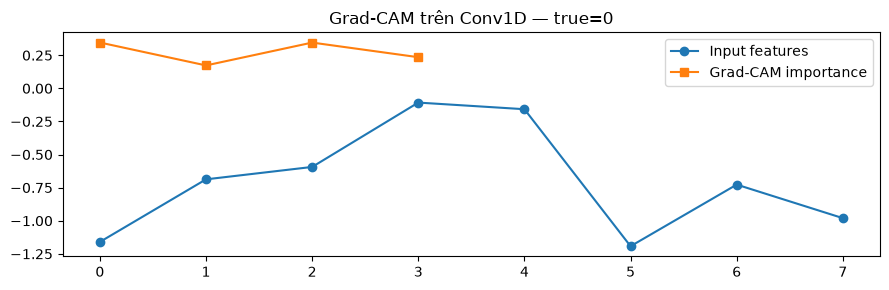

In [22]:
# Cell 14: Grad-CAM đơn giản cho Conv1D (dựa trên gradient của lớp Conv cuối)
class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.activations = None; self.gradients = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)
    def _fwd_hook(self, m, i, o): self.activations = o.detach()
    def _bwd_hook(self, m, gi, go): self.gradients = go[0].detach()
    def __call__(self, x, class_idx=1):
        self.model.eval()
        x = x.clone().requires_grad_(True)
        out = self.model(x)
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=2, keepdim=True)  # GAP theo vị trí
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        return cam

cam = GradCAM1D(improved, improved.features[-3])  # lớp Conv1d cuối
sample = X_te_t[0:1]
cam_vals = cam(sample, class_idx=int(y_te[0]))

plt.figure(figsize=(9, 3))
plt.plot(sample.squeeze().cpu().numpy(), label='Input features', marker='o')
plt.plot(cam_vals, label='Grad-CAM importance', marker='s')
plt.title(f"Grad-CAM trên Conv1D — true={y_te[0]}")
plt.legend(); plt.tight_layout()
plt.savefig("outputs/diabetes_gradcam.png", dpi=200); plt.show()

In [23]:
# Cell 15: Lưu tất cả kết quả
results = pd.DataFrame([
    {'Framework':'NumPy Scratch','Params':np_params,'Accuracy':np_acc,'F1':np_f1,'Time(s)':np_time},
    {'Framework':'PyTorch Baseline','Params':sum(p.numel() for p in baseline.parameters()),
     'Accuracy':acc_b,'F1':f1_b,'Time(s)':time_baseline},
    {'Framework':'PyTorch Improved','Params':sum(p.numel() for p in improved.parameters()),
     'Accuracy':acc_i,'F1':f1_i,'Time(s)':time_improved},
])
print(results.to_string(index=False))
results.to_csv("outputs/diabetes_framework_comparison.csv", index=False)

       Framework  Params  Accuracy       F1  Time(s)
   NumPy Scratch    5793  0.758621 0.611111 3.423226
PyTorch Baseline    1762  0.758621 0.621622 4.662227
PyTorch Improved   10722  0.758621 0.611111 4.507939
